In [70]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.cluster import DBSCAN
from sklearn.cluster import OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import seaborn as sns
import plotly.graph_objects as go
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [71]:
custom = pd.read_csv('customer_features_with_clusters.csv')
master = pd.read_csv('master_transactions.csv')

# Feature engineering and preprocessing

In [72]:
# 1. Calculate the actual Transaction Value for every row
master['transaction_value'] = master['list_price'] * master['Quantity']

# 2. Group by Customer to find the "Net Spenders"
customer_financials = master.groupby('customer_id').agg(
    total_net_spend=('transaction_value', 'sum'),
    total_items_handled=('Quantity', 'sum'),
    transaction_count=('customer_id', 'count')
)

# 3. Identify customers where Total Net Spend is negative
negative_spend_ids = customer_financials[customer_financials['total_net_spend'] < 0].index.tolist()

# 4. Extract their full history from the Master DF
negative_audit_df = master[master['customer_id'].isin(negative_spend_ids)].copy()
negative_audit_df = negative_audit_df.sort_values(by=['customer_id', 'Date'])

# 5. Export to CSV
negative_audit_df.to_csv('negative_spend_audit_detailed.csv', index=False)

print(f"Found {len(negative_spend_ids)} customers with a negative total balance.")
print("Detailed transaction history saved to 'negative_spend_audit_detailed.csv'")

# Quick look at the 'Top Returners' by value
print("\nCustomers with the most negative balances:")
print(customer_financials.loc[negative_spend_ids].sort_values('total_net_spend').head())

Found 52 customers with a negative total balance.
Detailed transaction history saved to 'negative_spend_audit_detailed.csv'

Customers with the most negative balances:
             total_net_spend  total_items_handled  transaction_count
customer_id                                                         
H0427042             -1602.5                   -6                 38
F0962981              -648.0                   -6                 19
L0411143              -629.0                   -4                 21
E0474206              -574.5                   -2                 14
L0532629              -510.0                   -4                 12


### 52 customers received multiple (2-3) returns for each product they bought and returned. The subsequent returns occured usually a week or two after the initial return

In [73]:
custom = custom.drop('cluster', axis=1)

In [74]:
master['transaction_value'] = master['list_price'] * master['Quantity']

# Calculate the total lifetime value (LTV) for every customer in the dataset
customer_check = master.groupby('customer_id')['transaction_value'].sum()

# Identify 'Valid' IDs (those who have spent €0.00 or more in total)
valid_customer_ids = customer_check[customer_check >= 0].index

# Create a clean master dataframe excluding the negative spenders
master = master[master['customer_id'].isin(valid_customer_ids)].copy()

In [75]:
# Converting Date and calculating Recency (Days since last purchase relative to Feb 28, 2025)
master['Date'] = pd.to_datetime(master['Date'], format='%d%b%Y', errors='coerce')

In [76]:
# Reference date for Recency (Feb 28, 2025)
ref_date = master['Date'].max()

# Recency: How many days ago was their last transaction
recency_df = master.groupby('customer_id')['Date'].max().reset_index()
recency_df['recency_days'] = (ref_date - recency_df['Date']).dt.days

# Pulling demographics from master 
demographics = master[['customer_id', 'Gender', 'province']].drop_duplicates('customer_id')

In [77]:
# MERGING INTO FINAL CLUSTERING TABLE
df_final = custom.merge(recency_df[['customer_id', 'recency_days']], on='customer_id', how='left')
df_final = df_final.merge(demographics, on='customer_id', how='left')

In [78]:
# Handle missing recency: if a customer is in 'custom' but not 'master', 
# they haven't purchased in the timeframe. Set to a high value, in this case 600 days
df_final['recency_days'] = df_final['recency_days'].fillna(600)

In [79]:
# PREPROCESSING
# Use standard scaler for numerical features and one-hot encoding for categorical
num_cols = ['age_years', 'net_amount', 'transaction_count', 'return_rate_tx', 
            'nl_open_rate', 'nl_click_rate', 'recency_days']
cat_cols = ['Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# Drop any rows where numerical data is missing before scaling
df_final = df_final.dropna(subset=num_cols)

X_scaled = preprocessor.fit_transform(df_final)

# K-means

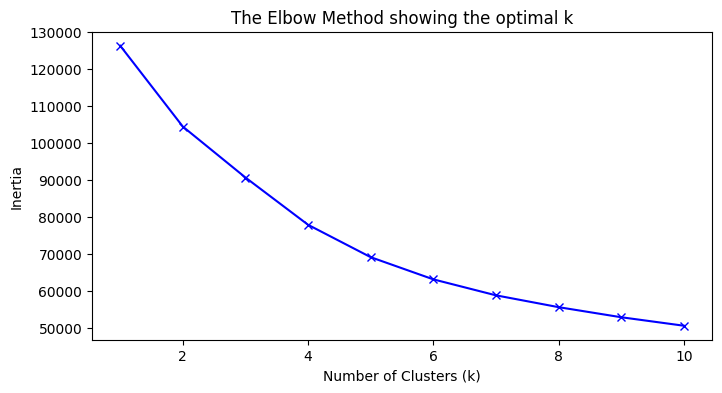

In [80]:
# ELBOW METHOD
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [81]:
# RUNNING K-MEANS 
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

In [82]:
# ANALYZE THE RESULTS
cluster_summary = df_final.groupby('cluster')[num_cols].mean()
print(cluster_summary)

         age_years   net_amount  transaction_count  return_rate_tx  \
cluster                                                              
0        49.105740   378.069516           3.197266        0.003431   
1        48.747542   261.952273           7.700317        0.356372   
2        49.185066   387.447947           3.303768        0.005412   
3        49.036633  1362.163473          11.220448        0.029601   

         nl_open_rate  nl_click_rate  recency_days  
cluster                                             
0            0.241464       0.037221    235.455379  
1            0.472048       0.146292    192.305497  
2            0.816455       0.339208    226.522227  
3            0.492261       0.156417     84.041176  


# DBSCAN

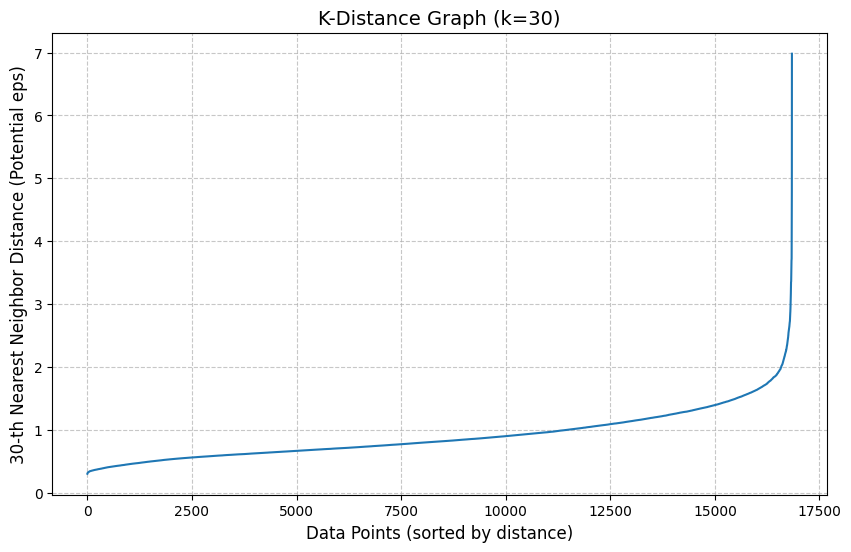

In [83]:
# Plot k-distance knee to find optimal epsilon (eps)
def plot_k_distance(data, k=30):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    
    distances, indices = neighbors_fit.kneighbors(data)

    k_distances = np.sort(distances[:, k-1], axis=0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_distances)
    plt.title(f'K-Distance Graph (k={k})', fontsize=14)
    plt.xlabel('Data Points (sorted by distance)', fontsize=12)
    plt.ylabel(f'{k}-th Nearest Neighbor Distance (Potential eps)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_k_distance(X_scaled, k=30)

In [84]:
# INITIALIZE DBSCAN
dbscan = DBSCAN(eps=1.8, min_samples=30)

clusters_dbscan = dbscan.fit_predict(X_scaled)

df_final['cluster_dbscan'] = clusters_dbscan

n_clusters_ = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_ = list(clusters_dbscan).count(-1)

print(f'Estimated number of clusters: {n_clusters_}')
print(f'Estimated number of noise points: {n_noise_}')

dbscan_summary = df_final[df_final['cluster_dbscan'] != -1].groupby('cluster_dbscan')[num_cols].mean()
print("\n--- DBSCAN Cluster Averages ---")
print(dbscan_summary)

Estimated number of clusters: 1
Estimated number of noise points: 119

--- DBSCAN Cluster Averages ---
                age_years  net_amount  transaction_count  return_rate_tx  \
cluster_dbscan                                                             
0               49.080947  574.020289           5.348861        0.046925   

                nl_open_rate  nl_click_rate  recency_days  
cluster_dbscan                                             
0                   0.480443       0.157305    195.106261  


# OPTICS

In [85]:
# OPTICS will find the best epsilon for each cluster automatically
optics_model = OPTICS(min_samples=15, xi=0.05, min_cluster_size=0.05)
df_final['cluster_optics'] = optics_model.fit_predict(X_scaled)

print("--- OPTICS Cluster Sizes ---")
print(df_final['cluster_optics'].value_counts())

--- OPTICS Cluster Sizes ---
cluster_optics
0    16842
Name: count, dtype: int64


### Hairball problem, DBSCAN and OPTICS won't work as the data is a "Global Density" mass -> no clear gaps between customer groups. Need centroid-based or distribution-based clustering

# Gaussian Mixture Model

In [86]:
# 1. Initialize GMM
gmm = GaussianMixture(n_components=4, random_state=42)

df_final['cluster_gmm'] = gmm.fit_predict(X_scaled)

gmm_summary = df_final.groupby('cluster_gmm')[num_cols].mean().round(2)
print("--- GMM Cluster Averages ---")
print(gmm_summary)

--- GMM Cluster Averages ---
             age_years  net_amount  transaction_count  return_rate_tx  \
cluster_gmm                                                             
0                48.84      304.27               6.19            0.32   
1                49.04     -237.76              12.40            0.56   
2                49.12      538.05               4.31            0.00   
3                48.87     1103.61              13.21            0.19   

             nl_open_rate  nl_click_rate  recency_days  
cluster_gmm                                             
0                    0.50           0.17        235.37  
1                    0.49           0.21        600.00  
2                    0.48           0.16        206.76  
3                    0.47           0.15         72.62  


In [87]:
# cluster sizes
print("--- Raw Cluster Sizes ---")
print(df_final['cluster_gmm'].value_counts())

print("\n--- Percentage Breakdown ---")
print(df_final['cluster_gmm'].value_counts(normalize=True) * 100)

--- Raw Cluster Sizes ---
cluster_gmm
2    13599
3     1784
0     1414
1       45
Name: count, dtype: int64

--- Percentage Breakdown ---
cluster_gmm
2    80.744567
3    10.592566
0     8.395677
1     0.267189
Name: proportion, dtype: float64


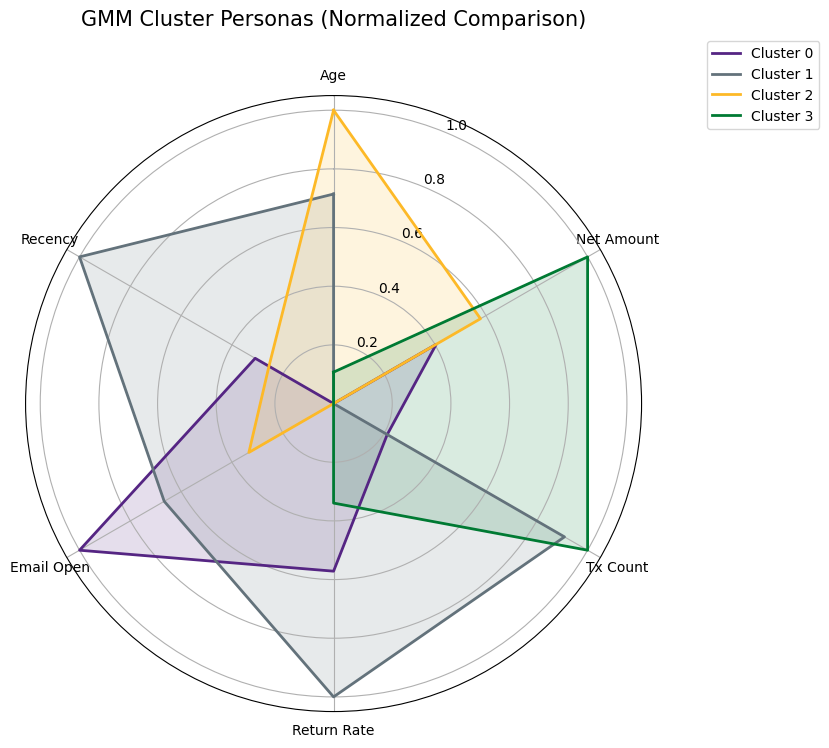

In [88]:
# Radar chart for GMM
labels = ['Age', 'Net Amount', 'Tx Count', 'Return Rate', 'Email Open', 'Recency']
stats = gmm_summary[['age_years', 'net_amount', 'transaction_count', 'return_rate_tx', 'nl_open_rate', 'recency_days']]

stats_norm = (stats - stats.min()) / (stats.max() - stats.min())

data_array = stats_norm.values 

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

data_plot = np.concatenate((data_array, data_array[:, [0]]), axis=1)
angles_plot = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#552583', '#63727b', '#fdb927', '#007a33'] 

for i in range(len(data_plot)):
    ax.plot(angles_plot, data_plot[i], color=colors[i], linewidth=2, label=f'Cluster {i}')
    ax.fill(angles_plot, data_plot[i], color=colors[i], alpha=0.15)

ax.set_thetagrids(np.degrees(angles), labels)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.title('GMM Cluster Personas (Normalized Comparison)', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

# Hierarchical clustering

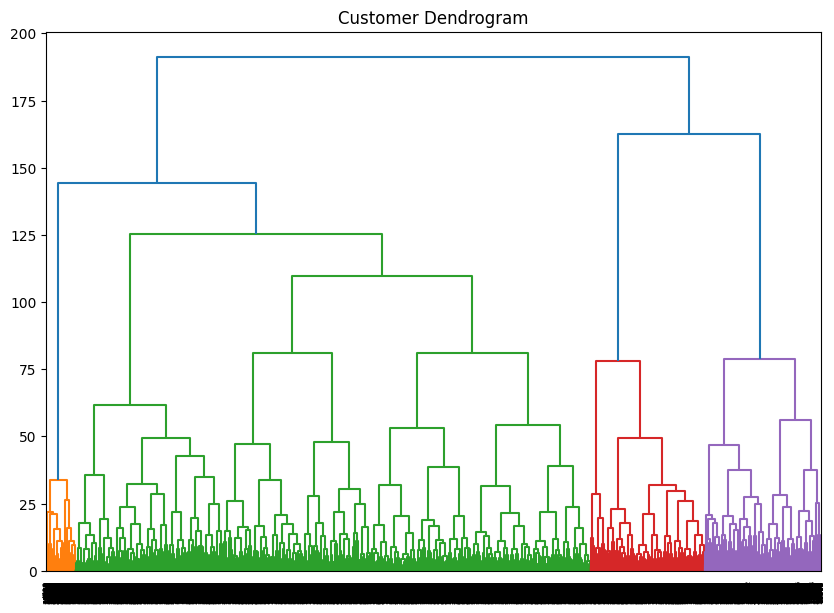

--- Hierarchical Clustering Averages ---
            age_years  net_amount  transaction_count  return_rate_tx  \
cluster_hc                                                             
0               48.86      421.55               3.50            0.00   
1               48.70      420.60               8.74            0.31   
2               50.31     1487.80              11.41            0.01   
3               49.43      364.69               3.10            0.02   

            nl_open_rate  nl_click_rate  recency_days  
cluster_hc                                             
0                   0.46           0.11        224.28  
1                   0.47           0.14        166.81  
2                   0.48           0.16         83.31  
3                   1.00           1.00        252.52  

--- Cluster Sizes ---
cluster_hc
0    11206
1     2517
2     2480
3      639
Name: count, dtype: int64


In [89]:
# VISUALIZE THE DENDROGRAM
plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram")
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.show()

# RUN THE CLUSTERING
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df_final['cluster_hc'] = hc.fit_predict(X_scaled)

hc_summary = df_final.groupby('cluster_hc')[num_cols].mean().round(2)
print("--- Hierarchical Clustering Averages ---")
print(hc_summary)

print("\n--- Cluster Sizes ---")
print(df_final['cluster_hc'].value_counts().sort_index())

In [90]:
# See which provinces have the most VIPs (Cluster 2)
vip_provinces = df_final[df_final['cluster_hc'] == 2]['province'].value_counts().head(10)
print("Top 10 Provinces for VIPs:\n", vip_provinces)

Top 10 Provinces for VIPs:
 province
Roma       153
Napoli     119
Milano     118
Torino      99
Palermo     62
Bari        53
Verona      50
Salerno     49
Brescia     49
Catania     48
Name: count, dtype: int64


In [91]:
# Find provinces with a high number of VIPs RELATIVE to the national average
total_vips = len(df_final[df_final['cluster_hc'] == 2])
total_customers = len(df_final)
global_vip_rate = total_vips / total_customers

province_stats = df_final.groupby('province').agg(
    total_in_province=('customer_id', 'count'),
    vips_in_province=('cluster_hc', lambda x: (x == 2).sum())
)

# Filter out provinces with very few customers to avoid statistical "noise"
min_sample_size = 50 
province_stats = province_stats[province_stats['total_in_province'] >= min_sample_size].copy()

province_stats['actual_vip_rate'] = province_stats['vips_in_province'] / province_stats['total_in_province']
province_stats['vip_index'] = (((province_stats['actual_vip_rate'] / global_vip_rate) * 100)).round(1)

top_hotspots = province_stats.sort_values('vip_index', ascending=False).head(10)

print(f"Global VIP Baseline: {global_vip_rate:.2%}")
print("\n--- Top 10 Over-Performing Provinces (Hot Spots) ---")
print(top_hotspots[['total_in_province', 'vips_in_province', 'vip_index']])

Global VIP Baseline: 14.73%

--- Top 10 Over-Performing Provinces (Hot Spots) ---
                       total_in_province  vips_in_province  vip_index
province                                                             
Terni                                 64                16      169.8
Cagliari                             170                36      143.8
Trieste                               67                14      141.9
Brindisi                             125                26      141.3
Benevento                             68                14      139.8
Ragusa                                88                18      138.9
Barletta-Andria-Trani                100                20      135.8
Lodi                                  83                16      130.9
Udine                                193                36      126.7
Cremona                               97                18      126.0


# Evaluation of HC

In [92]:
X = X_scaled  # The features used for clustering
labels = df_final['cluster_hc']

# 1. Calculate the Scores
sil = silhouette_score(X, labels)
ch = calinski_harabasz_score(X, labels)
db = davies_bouldin_score(X, labels)

print(f"--- Hierarchical Clustering Evaluation (k=4) ---")
print(f"Silhouette Score: {sil:.4f}  (Higher is better, >0.2 is good)")
print(f"Calinski-Harabasz: {ch:.2f} (Higher is better)")
print(f"Davies-Bouldin:   {db:.4f}  (Lower is better, closer to 0 is better)")

# 2. Comparative Analysis 
eval_results = []
for k in [3, 4, 5, 6]:
    model = AgglomerativeClustering(n_clusters=k)
    temp_labels = model.fit_predict(X)
    
    eval_results.append({
        'k': k,
        'Silhouette': silhouette_score(X, temp_labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, temp_labels),
        'Davies-Bouldin': davies_bouldin_score(X, temp_labels)
    })

eval_df = pd.DataFrame(eval_results)
print("\n--- Comparative Metrics by Number of Clusters ---")
print(eval_df.to_string(index=False))

--- Hierarchical Clustering Evaluation (k=4) ---
Silhouette Score: 0.2072  (Higher is better, >0.2 is good)
Calinski-Harabasz: 2783.75 (Higher is better)
Davies-Bouldin:   1.4182  (Lower is better, closer to 0 is better)

--- Comparative Metrics by Number of Clusters ---
 k  Silhouette  Calinski-Harabasz  Davies-Bouldin
 3    0.190152        2794.455861        1.621965
 4    0.207237        2783.753246        1.418223
 5    0.145478        2732.621351        1.642865
 6    0.134848        2659.372317        1.652712
